In [1]:
# Welcome to your new notebook
# Type here in the cell editor to add code!

# Azure Blob Storage access info
blob_account_name = "azureopendatastorage"
blob_container_name = "nyctlc"
blob_relative_path = "yellow"

# blob_sas_token = "add your SAS token here" # Construct the path for connection
wasbs_path = f'wasbs://{blob_container_name}@{blob_account_name}.blob.core.windows.net/{blob_relative_path}'

# WASBS path for connection including SAS token
# wasbs_path = f'wasbs://{blob_container_name}@{blob_account_name}.blob.core.windows.net/{blob_relative_path}?{blob_sas_token}'

# Read parquet data from Azure Blob Storage path
blob_df = spark.read.parquet(wasbs_path)

# Display the Azure Blob DataFrame
display(blob_df)




StatementMeta(, 440e4147-2fef-4195-b1da-7f7192872f23, 3, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, c2db5364-5ee8-4f68-b6ce-65de537b10bb)

In [5]:
print("Number of columns:", len(blob_df.columns))
display(blob_df.columns)


StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 7, Finished, Available, Finished)

Number of columns: 23


SynapseWidget(Synapse.DataFrame, f5db50f6-06a5-4ee0-a341-a807b6dc2b14)

In [2]:
selected_df = (
    blob_df
        .select(
            "vendorID",
            "tpepPickupDateTime",
            "tpepDropoffDateTime",
            "passengerCount",
            "tripDistance",
            "endLon",
            "endLat",
            "rateCodeId",
            "storeAndFwdFlag",
            "paymentType",
            "fareAmount",
            "totalAmount",
            "puYear",
            "puMonth"
        )
        .withColumnRenamed("puYear", "Year")
        .withColumnRenamed("puMonth", "Month")
)

display(selected_df)

StatementMeta(, 440e4147-2fef-4195-b1da-7f7192872f23, 4, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, d1ccb648-7ec7-425a-806c-c097a1780570)

In [20]:
# NO of records in the table 

selected_df.count()

StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 22, Finished, Available, Finished)

1571671152

In [9]:
#save the file in Lakehouse
selected_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("Files/Azureblob/Vendor")

StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 11, Submitted, Running, Running)

In [12]:
#delete the Vendor folder
mssparkutils.fs.rm("Files/Azureblob/Vendor", True)

StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 14, Finished, Available, Finished)

True

In [13]:
#delete the Azureblob folder
mssparkutils.fs.rm("Files/Azureblob", True)

StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 15, Finished, Available, Finished)

True

In [14]:
#want to save the data in CSV format

selected_df.write \
    .format("csv") \
    .option("header", "true") \
    .mode("overwrite") \
    .save("Files/Azureblob/Vendor")

StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 16, Finished, Available, Finished)

In [15]:
#delete the Vendor folder
mssparkutils.fs.rm("Files/Azureblob/Vendor", True)

StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 17, Finished, Available, Finished)

True

In [6]:
#delete the Azureblob folder
mssparkutils.fs.rm("Files/Azureblob", True)

StatementMeta(, 440e4147-2fef-4195-b1da-7f7192872f23, 8, Finished, Available, Finished)

True

In [17]:
# check what are the values in VendorID
selected_df.select("vendorID").distinct().show()

StatementMeta(, 993e4dbc-62bb-4cd9-a70d-a02f440e1ec9, 19, Submitted, Running, Running)

+--------+
|vendorID|
+--------+
|     CMT|
|     VTS|
|     DDS|
|       1|
|       2|
|       3|
|       4|
+--------+



In [12]:
# Count of Filtered 

filtered_df.count() 

StatementMeta(, a4315b75-c68b-4801-806d-788c9c74a6c9, 14, Finished, Available, Finished)

35886450

In [5]:
# Saving this in my lakehouse

filtered_df.write \
    .format("csv") \
    .option("header", "true") \
    .mode("overwrite") \
    .save("Files/Azureblob/Vendor")

StatementMeta(, cb9994d3-7c1d-460b-a292-7d5dc89583e2, 7, Finished, Available, Finished)

In [3]:
# Filtered with vendor "CMT", "VTS", "DDS" , Total Amount Greater than 100

filtered_df = selected_df.filter(
    (selected_df.vendorID.isin("CMT", "VTS", "DDS")) &
    (selected_df.totalAmount > 100)
)

display(filtered_df)

StatementMeta(, 440e4147-2fef-4195-b1da-7f7192872f23, 5, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 2e19cfc6-f5ea-474f-a335-d961c27d3fa0)

In [8]:
# Count of Filtered_df

display(filtered_df.count())

StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 10, Finished, Available, Finished)

607610

In [10]:
#Total trips per vendor

from pyspark.sql.functions import count

vendor_trip_counts = (
    filtered_df
    .groupBy("vendorID")
    .agg(count("*").alias("total_trips"))
)

vendor_trip_counts.show()

StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 12, Finished, Available, Finished)

+--------+-----------+
|vendorID|total_trips|
+--------+-----------+
|     CMT|     266570|
|     VTS|     336057|
|     DDS|       4983|
+--------+-----------+



In [12]:
# registering the datafrmae to use SQL query
filtered_df.createOrReplaceTempView("filtered_df")

StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 14, Finished, Available, Finished)

In [13]:
%%sql

/*Total trips per vendor using SQL*/

select vendorID, count(*) as Total_Trips
from filtered_df
group BY  vendorID

StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 15, Finished, Available, Finished)

<Spark SQL result set with 3 rows and 2 fields>

In [19]:
# Average Fare for VendorID

from pyspark.sql.functions import avg, round

avg_fare_vendor = (
    filtered_df
    .groupBy("vendorID")
    .agg(round(avg("fareAmount"), 1).alias("avg_fare"))
    .orderBy("vendorID")
)

avg_fare_vendor.show()

StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 21, Finished, Available, Finished)

+--------+--------+
|vendorID|avg_fare|
+--------+--------+
|     CMT|   115.2|
|     DDS|   110.5|
|     VTS|   111.4|
+--------+--------+



In [27]:
# Total revenue per payment type

from pyspark.sql.functions import sum, round, col

revenue_vendor = (
    filtered_df
    .groupBy("vendorID")
    .agg(round(sum("totalAmount"), 2).alias("total_revenue"))
    .withColumn("total_revenue", col("total_revenue").cast("string"))
    .orderBy("vendorID")
)

revenue_vendor.show(truncate=False)

StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 29, Finished, Available, Finished)

+--------+-------------+
|vendorID|total_revenue|
+--------+-------------+
|CMT     |3.680867322E7|
|DDS     |646172.24    |
|VTS     |4.664562542E7|
+--------+-------------+



StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 32, Finished, Available, Finished)

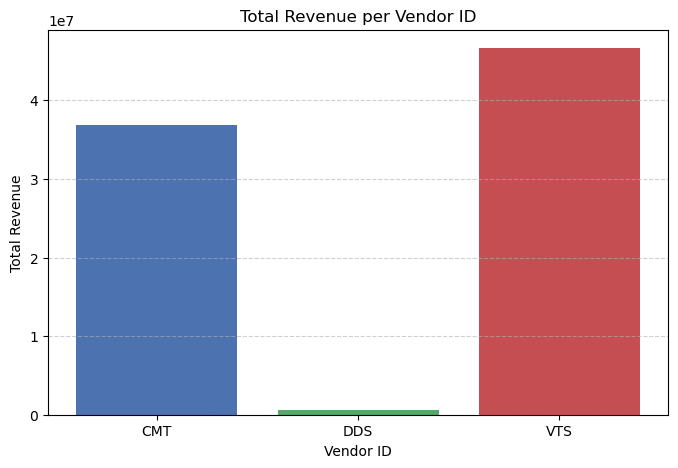

In [30]:
# Total Revenue per VendorID in barchart using python

from pyspark.sql.functions import sum, round
import matplotlib.pyplot as plt

# 1. Aggregate revenue per vendor
revenue_vendor = (
    filtered_df
    .groupBy("vendorID")
    .agg(round(sum("totalAmount"), 2).alias("total_revenue"))
    .orderBy("vendorID")
)

# 2. Collect results into Python lists
result = revenue_vendor.collect()
vendor_ids = [row["vendorID"] for row in result]
revenues = [row["total_revenue"] for row in result]

# 3. Plot the bar chart
plt.figure(figsize=(8, 5))
plt.bar(vendor_ids, revenues, color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Total Revenue per Vendor ID")
plt.xlabel("Vendor ID")
plt.ylabel("Total Revenue")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

StatementMeta(, a5d805e6-ad97-4ead-8c84-23b02a8d0e3b, 33, Finished, Available, Finished)

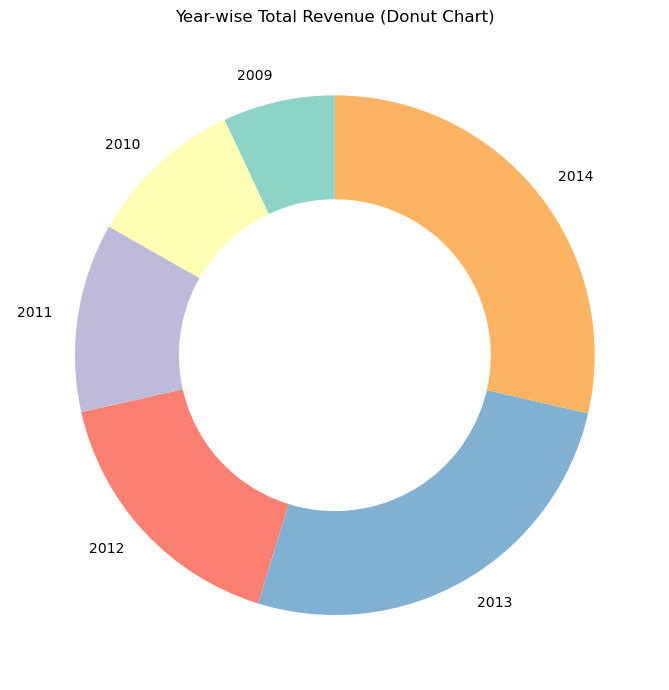

In [31]:
#Donut chart showing year wise Revenue

from pyspark.sql.functions import sum, round
import matplotlib.pyplot as plt

# 1. Aggregate total revenue per year
revenue_year = (
    filtered_df
    .groupBy("Year")
    .agg(round(sum("totalAmount"), 2).alias("total_revenue"))
    .orderBy("Year")
)

# 2. Collect results into Python lists
result = revenue_year.collect()
years = [row["Year"] for row in result]
revenues = [row["total_revenue"] for row in result]

# 3. Donut chart
plt.figure(figsize=(7, 7))
colors = plt.cm.Set3(range(len(years)))

# Pie chart
wedges, texts = plt.pie(revenues, labels=years, colors=colors, startangle=90)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Year-wise Total Revenue (Donut Chart)")
plt.tight_layout()
plt.show()

In [4]:

# Filtered with vendor  "VTS", "DDS" , Total Amount Greater than120

filtered_vendor_df = (
    filtered_df
    .filter(
        (filtered_df.vendorID.isin("VTS", "DDS")) &
        (filtered_df.totalAmount > 120)
    )
    .select(
        "vendorID",
        "passengerCount",
        "paymentType",
        "totalAmount",
        "Year"
    )
)

filtered_vendor_df.show()

StatementMeta(, 440e4147-2fef-4195-b1da-7f7192872f23, 6, Finished, Available, Finished)

+--------+--------------+-----------+-----------+----+
|vendorID|passengerCount|paymentType|totalAmount|Year|
+--------+--------------+-----------+-----------+----+
|     VTS|             6|        CRD|     189.88|2012|
|     VTS|             1|        CSH|      450.5|2012|
|     VTS|             1|        CSH|      360.0|2012|
|     VTS|             1|        CRD|      230.0|2012|
|     VTS|             1|        CRD|      122.0|2012|
|     VTS|             1|        CRD|      132.6|2012|
|     VTS|             1|        CRD|      123.0|2012|
|     VTS|             1|        CRD|      122.0|2012|
|     VTS|             5|        CRD|      120.3|2012|
|     VTS|             1|        CRD|      142.3|2012|
|     VTS|             4|        CRD|      152.4|2012|
|     VTS|             1|        CRD|      150.0|2012|
|     VTS|             1|        CRD|      400.0|2012|
|     VTS|             1|        CSH|      132.5|2012|
|     VTS|             1|        CRD|      126.0|2012|
|     VTS|

In [7]:
# Save this file in single CSV

filtered_vendor_df \
    .coalesce(1) \
    .write \
    .format("csv") \
    .option("header", "true") \
    .mode("overwrite") \
    .save("Files/Azureblob/Vendor")

StatementMeta(, 440e4147-2fef-4195-b1da-7f7192872f23, 9, Submitted, Running, Running)